# Лабораторная работа №2.

**Цель:** демонстрация способности нейронной сети решать задачи классификации на примере решения задачи распознавания дефектов поверхности металлов на изображениях в оттенках серого цвета (определение одного из 6 типов дефектов).

В качестве модели машинного обучения необходимо реализовать модель свёрточной нейронной сети с использованием библиотек Keras и Tensorflow и языка Python.

**Выполнила:** студент группы 6231-090401D Ризванова Э.Т.

**Вариант 10:**
- Алгоритм 1 - Adamax;
- Алгоритм 2 - Nadam;
- Число слоёв свёртки - 3;
- Число слоёв субдискретизации - 2;
- Число слоёв dropout - 1;
- Функция активации - PReLU;
- Функция ошибки - sparse categorical crossentropy.

### 1. Импорт всех нужных библиотек

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import models, layers, optimizers
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### 2. Работа с данными

#### Скачивание данных:

In [3]:
import kagglehub

path = kagglehub.dataset_download("fantacher/neu-metal-surface-defects-data")

path += "/NEU Metal Surface Defects Data"
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'neu-metal-surface-defects-data' dataset.
Path to dataset files: /kaggle/input/neu-metal-surface-defects-data/NEU Metal Surface Defects Data


#### Считывание данных:

In [4]:
def load_dataset(path, batch_size, target_size=(200,200)):
    datagen = ImageDataGenerator(rescale=1./255)

    train_data = datagen.flow_from_directory(
        directory=os.path.join(path, 'train'),
        target_size=target_size,
        color_mode='grayscale',
        class_mode='sparse',
        batch_size=batch_size,
        shuffle=True,
        seed=SEED
    )

    valid_data = datagen.flow_from_directory(
        directory=os.path.join(path, 'valid'),
        target_size=target_size,
        color_mode='grayscale',
        class_mode='sparse',
        batch_size=batch_size,
        shuffle=False,
        seed=SEED
    )

    test_data = datagen.flow_from_directory(
        directory=os.path.join(path, 'test'),
        target_size=target_size,
        color_mode='grayscale',
        class_mode='sparse',
        batch_size=batch_size,
        shuffle=False,
        seed=SEED
    )

    return train_data, valid_data, test_data

### 3. Построение модели

In [5]:
def build_cnn_model(optimizer_name, dropout, learning_rate=0.001, input_shape=(200,200,1)):
    model = models.Sequential()
    model.add(layers.InputLayer(input_shape))

    model.add(layers.Conv2D(32, (3,3)))
    model.add(layers.PReLU())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(64, (3,3)))
    model.add(layers.PReLU())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(128, (3,3)))
    model.add(layers.PReLU())

    model.add(layers.Flatten())
    model.add(layers.Dense(128))
    model.add(layers.PReLU())

    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(6, activation='softmax'))

    if optimizer_name.lower() == 'adamax':
      optimizer = optimizers.Adamax(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'nadam':
      optimizer = optimizers.Nadam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    print(f"\nМодель создана: optimizer={optimizer_name}, learning_rate={learning_rate}")

    return model

### 4. Тестирование модели

#### Графики аккуратности и ошибки:

In [6]:
def plot_training_history(history, optimizer_name, epochs):
    _, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))

    ax1.plot(history.history['accuracy'], label='Обучение')
    ax1.plot(history.history['val_accuracy'], label='Валидация')
    ax1.set_title(f'Аккуратность {optimizer_name}')
    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('Аккуратность')
    ax1.set_xticks(range(0, epochs, 5))
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history.history['loss'], label='Обучение')
    ax2.plot(history.history['val_loss'], label='Валидация')
    ax2.set_title(f'Функция ошибки {optimizer_name}')
    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('Функция ошибки')
    ax2.set_xticks(range(0, epochs, 5))
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()

#### Матрица ошибок:

In [7]:
def plot_confusion_matrix(y_true, y_pred, class_names, optimizer_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Матрица ошибок {optimizer_name}')
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

#### Обучение и оценка модели:

In [8]:
def train_and_evaluate_model(model, optimizer_name, train_data, valid_data, test_data, epochs):
    print(f"\nОбучение модели...")
    history = model.fit(train_data, validation_data=valid_data, epochs=epochs, verbose=0)

    plot_training_history(history, optimizer_name, epochs)

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]

    print("\nРезультаты обучения:")
    print(f"Training Accuracy:    {train_acc:.4f}, Training Loss:    {train_loss:.4f}")
    print(f"Validation Accuracy:  {val_acc:.4f}, Validation Loss:  {val_loss:.4f}")

    test_data.reset()
    test_loss, test_acc = model.evaluate(test_data, verbose=0)
    print(f"\nРезультаты тестирования:")
    print(f"Test Accuracy:        {test_acc:.4f}, Test Loss:        {test_loss:.4f}\n")

    y_pred = np.argmax(model.predict(test_data, verbose=0), axis=1)
    y_true = test_data.classes
    class_names = list(train_data.class_indices.keys())

    plot_confusion_matrix(y_true, y_pred, class_names, optimizer_name)

    print("\nМетрики:")
    print(classification_report(y_true, y_pred, target_names=class_names))

### 5. Исследование зависимости функции ошибки и от числа эпох обучения

#### Adamax:


Параметры: epochs=15, batch_size=32, dropout=0.3

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Adamax, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9620, Training Loss:    0.1198
Validation Accuracy:  0.9444, Validation Loss:  0.1214

Результаты тестирования:
Test Accuracy:        0.9444, Test Loss:        0.1803



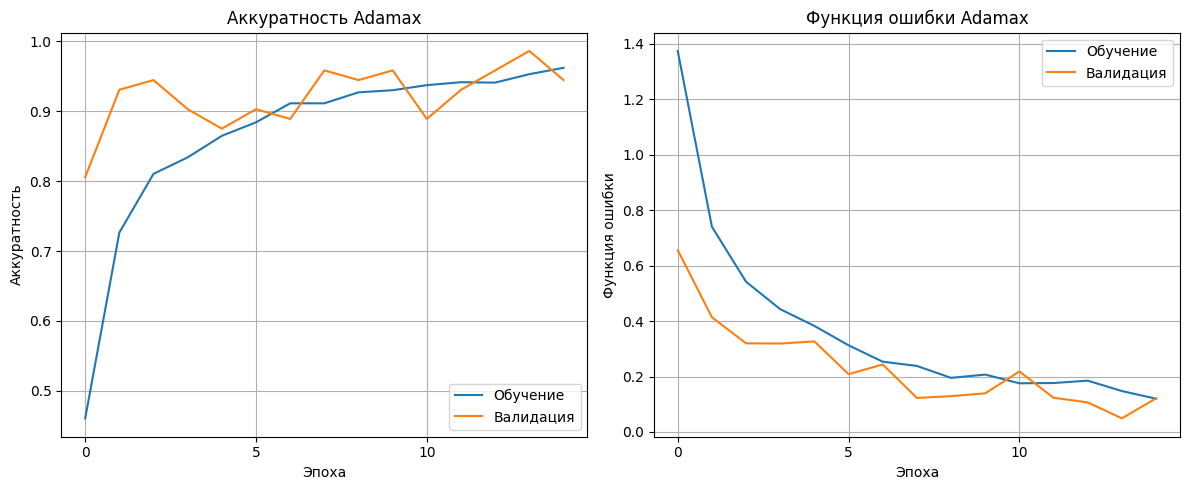

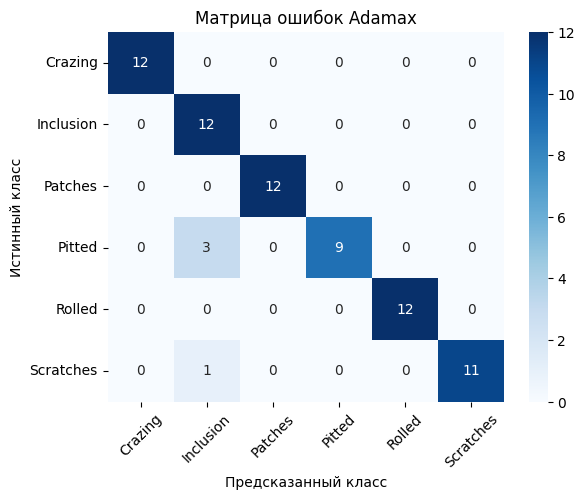


Метрики:
              precision    recall  f1-score   support

     Crazing       1.00      1.00      1.00        12
   Inclusion       0.75      1.00      0.86        12
     Patches       1.00      1.00      1.00        12
      Pitted       1.00      0.75      0.86        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      0.92      0.96        12

    accuracy                           0.94        72
   macro avg       0.96      0.94      0.95        72
weighted avg       0.96      0.94      0.95        72


Параметры: epochs=20, batch_size=32, dropout=0.3

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Adamax, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9656, Training Loss:    0.1011
Validation Accuracy:  0.9861, Validation Loss:  0.0527

Результаты тестирования:
Test Accuracy:        0.9583, Test Loss:        0.1299



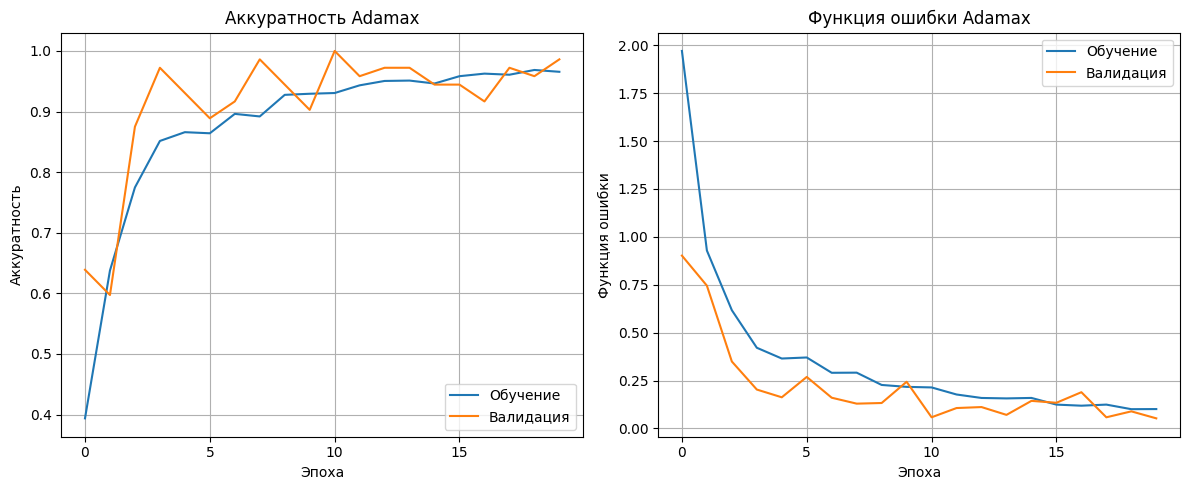

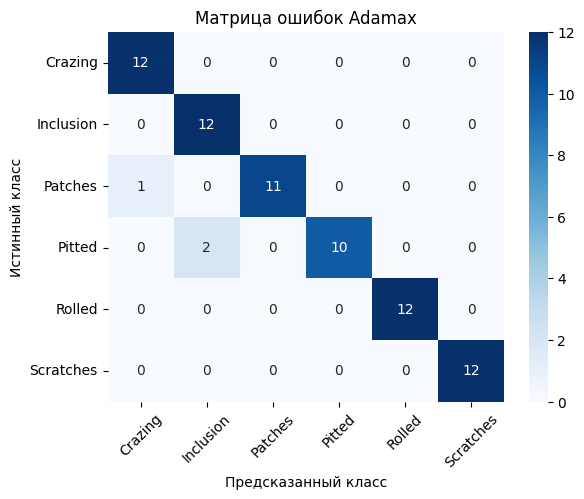


Метрики:
              precision    recall  f1-score   support

     Crazing       0.92      1.00      0.96        12
   Inclusion       0.86      1.00      0.92        12
     Patches       1.00      0.92      0.96        12
      Pitted       1.00      0.83      0.91        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      1.00      1.00        12

    accuracy                           0.96        72
   macro avg       0.96      0.96      0.96        72
weighted avg       0.96      0.96      0.96        72


Параметры: epochs=25, batch_size=32, dropout=0.3

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Adamax, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9746, Training Loss:    0.0696
Validation Accuracy:  0.9583, Validation Loss:  0.0827

Результаты тестирования:
Test Accuracy:        0.9583, Test Loss:        0.1463



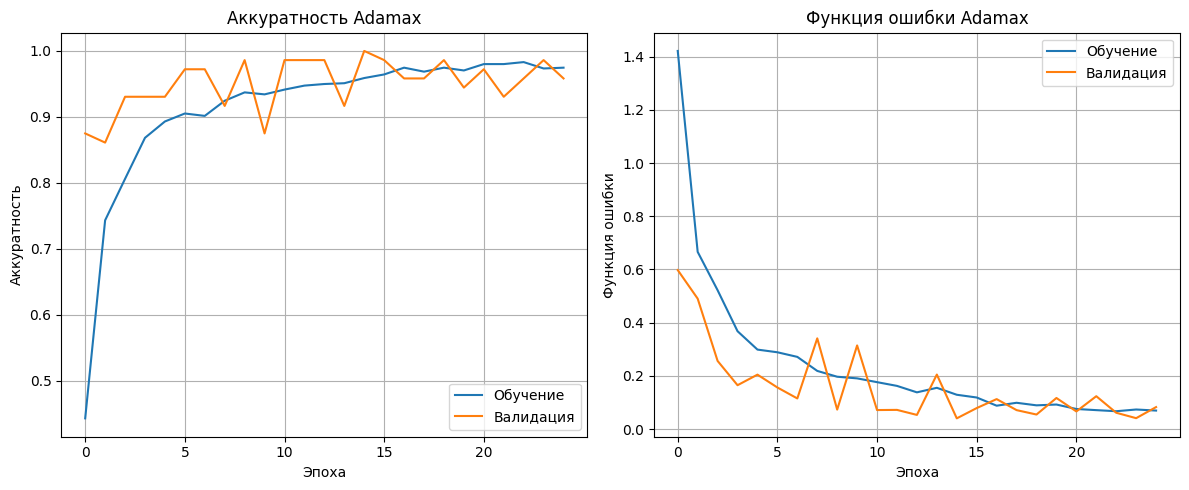

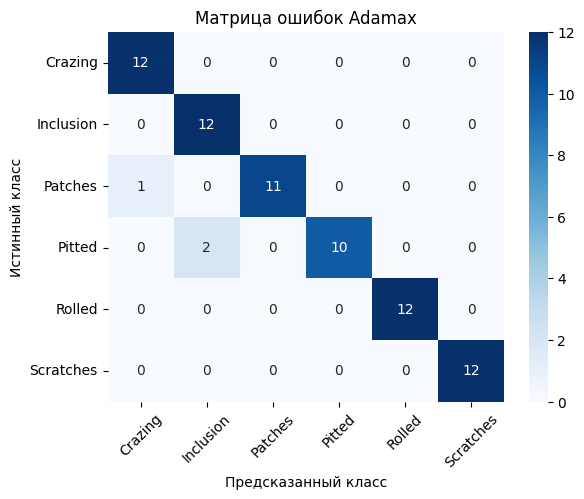


Метрики:
              precision    recall  f1-score   support

     Crazing       0.92      1.00      0.96        12
   Inclusion       0.86      1.00      0.92        12
     Patches       1.00      0.92      0.96        12
      Pitted       1.00      0.83      0.91        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      1.00      1.00        12

    accuracy                           0.96        72
   macro avg       0.96      0.96      0.96        72
weighted avg       0.96      0.96      0.96        72


Параметры: epochs=30, batch_size=32, dropout=0.3

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Adamax, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9891, Training Loss:    0.0491
Validation Accuracy:  0.9444, Validation Loss:  0.1202

Результаты тестирования:
Test Accuracy:        0.9306, Test Loss:        0.1335



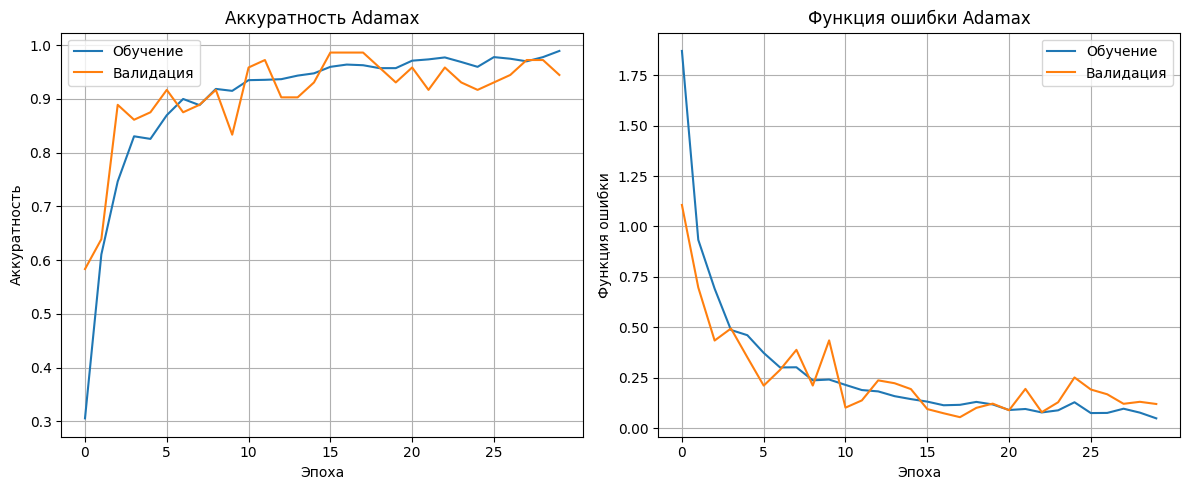

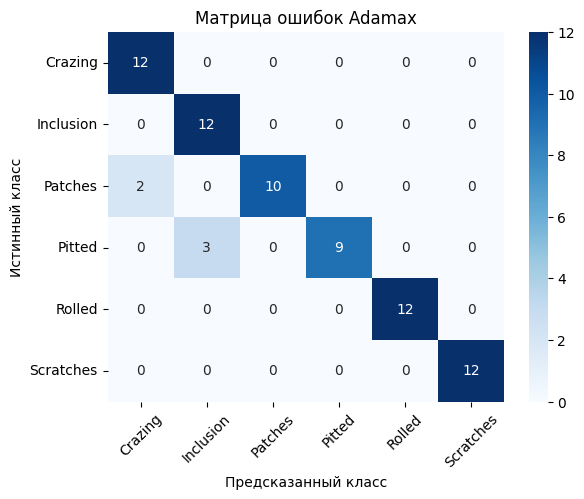


Метрики:
              precision    recall  f1-score   support

     Crazing       0.86      1.00      0.92        12
   Inclusion       0.80      1.00      0.89        12
     Patches       1.00      0.83      0.91        12
      Pitted       1.00      0.75      0.86        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      1.00      1.00        12

    accuracy                           0.93        72
   macro avg       0.94      0.93      0.93        72
weighted avg       0.94      0.93      0.93        72



In [ ]:
EPOCHS = 25
BATCH_SIZE = 32
DROPOUT_RATE = 0.3
OPTIMIZER = 'Adamax'

for ep in [15, 20, 25, 30]:
  print(f"\nПараметры: epochs={ep}, batch_size={BATCH_SIZE}, dropout={DROPOUT_RATE}\n")
  train_data, valid_data, test_data = load_dataset(path, BATCH_SIZE)
  model = build_cnn_model(OPTIMIZER, DROPOUT_RATE)
  train_and_evaluate_model(model, OPTIMIZER, train_data, valid_data, test_data, ep)

#### Nadam:


Параметры: epochs=15, batch_size=32, dropout=0.3

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Nadam, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9662, Training Loss:    0.1014
Validation Accuracy:  0.9583, Validation Loss:  0.0818

Результаты тестирования:
Test Accuracy:        0.9583, Test Loss:        0.1566



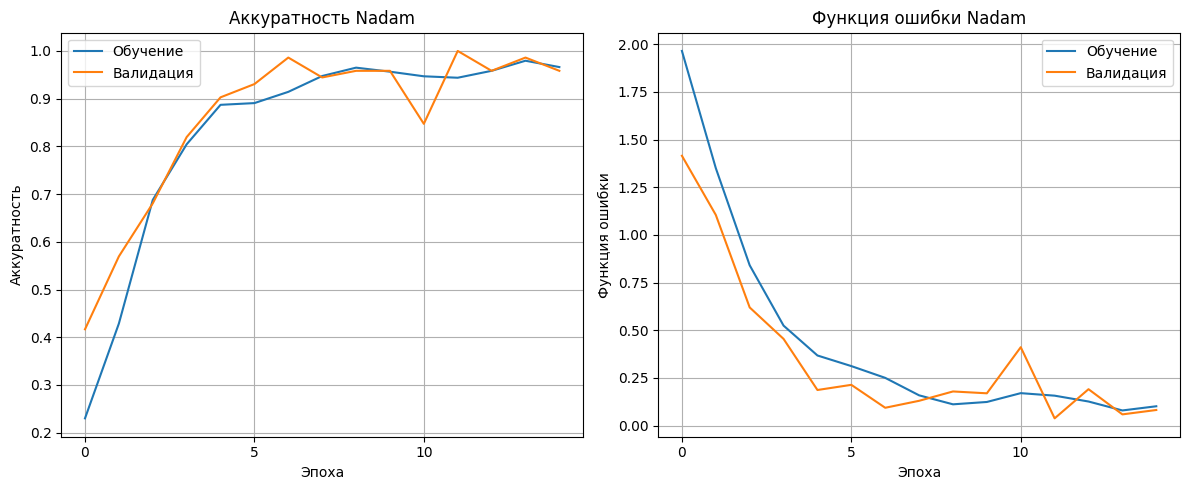

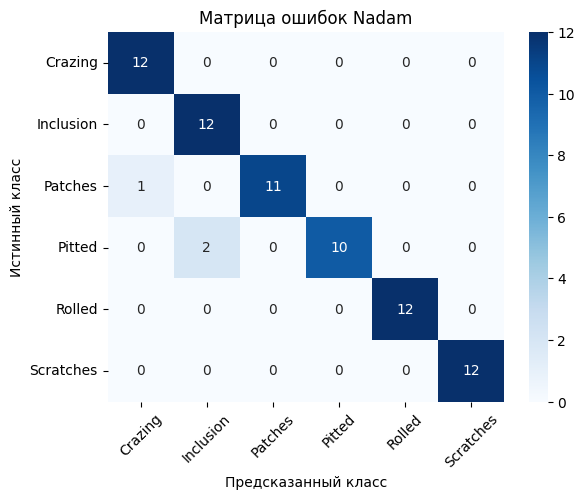


Метрики:
              precision    recall  f1-score   support

     Crazing       0.92      1.00      0.96        12
   Inclusion       0.86      1.00      0.92        12
     Patches       1.00      0.92      0.96        12
      Pitted       1.00      0.83      0.91        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      1.00      1.00        12

    accuracy                           0.96        72
   macro avg       0.96      0.96      0.96        72
weighted avg       0.96      0.96      0.96        72


Параметры: epochs=20, batch_size=32, dropout=0.3

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Nadam, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9783, Training Loss:    0.0723
Validation Accuracy:  0.9583, Validation Loss:  0.0836

Результаты тестирования:
Test Accuracy:        0.9861, Test Loss:        0.0648



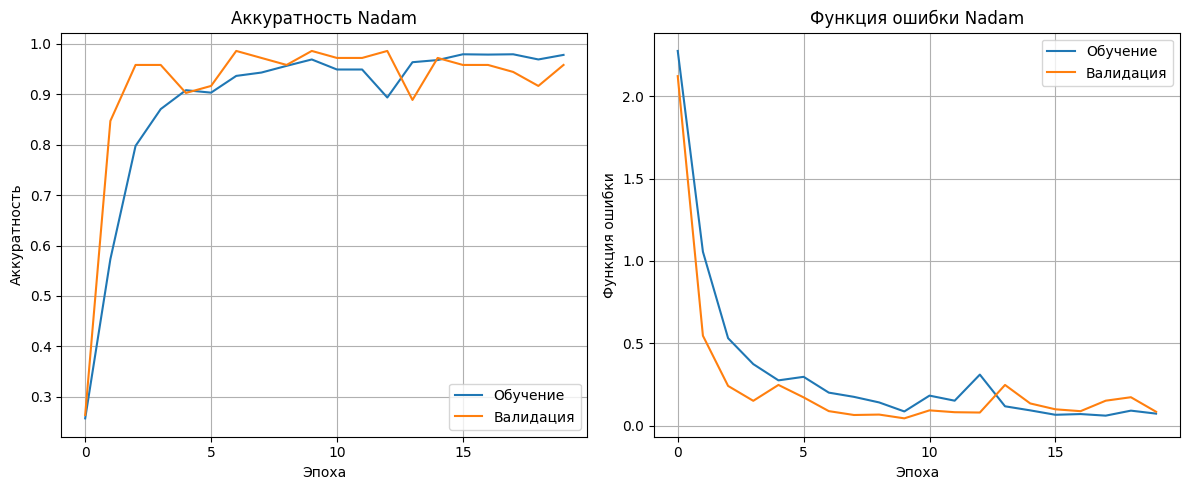

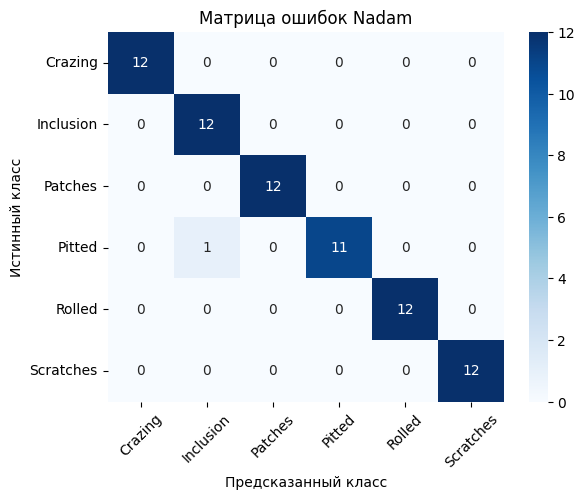


Метрики:
              precision    recall  f1-score   support

     Crazing       1.00      1.00      1.00        12
   Inclusion       0.92      1.00      0.96        12
     Patches       1.00      1.00      1.00        12
      Pitted       1.00      0.92      0.96        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      1.00      1.00        12

    accuracy                           0.99        72
   macro avg       0.99      0.99      0.99        72
weighted avg       0.99      0.99      0.99        72


Параметры: epochs=25, batch_size=32, dropout=0.3

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Nadam, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9861, Training Loss:    0.0499
Validation Accuracy:  0.9583, Validation Loss:  0.1940

Результаты тестирования:
Test Accuracy:        0.9444, Test Loss:        0.1101



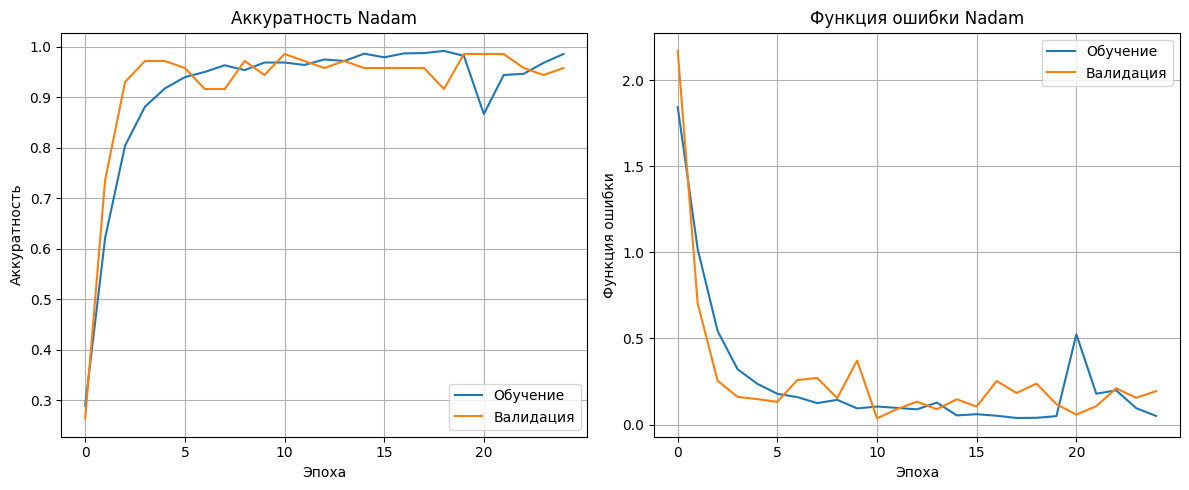

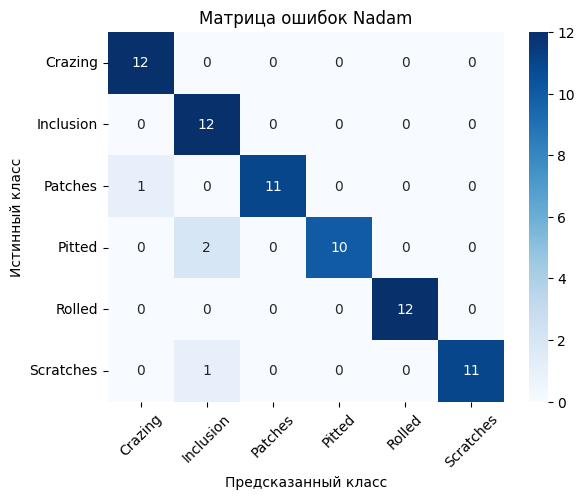


Метрики:
              precision    recall  f1-score   support

     Crazing       0.92      1.00      0.96        12
   Inclusion       0.80      1.00      0.89        12
     Patches       1.00      0.92      0.96        12
      Pitted       1.00      0.83      0.91        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      0.92      0.96        12

    accuracy                           0.94        72
   macro avg       0.95      0.94      0.95        72
weighted avg       0.95      0.94      0.95        72


Параметры: epochs=30, batch_size=32, dropout=0.3

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Nadam, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9843, Training Loss:    0.0609
Validation Accuracy:  0.9722, Validation Loss:  0.0429

Результаты тестирования:
Test Accuracy:        0.9444, Test Loss:        0.1900



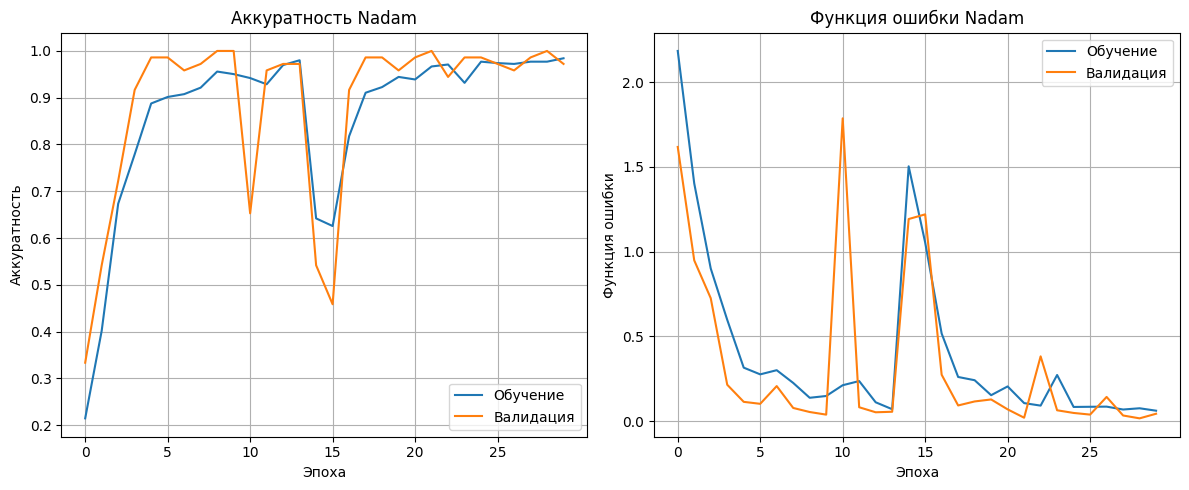

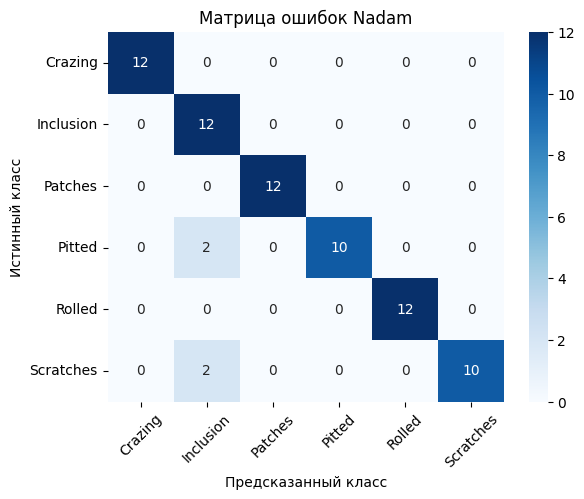


Метрики:
              precision    recall  f1-score   support

     Crazing       1.00      1.00      1.00        12
   Inclusion       0.75      1.00      0.86        12
     Patches       1.00      1.00      1.00        12
      Pitted       1.00      0.83      0.91        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      0.83      0.91        12

    accuracy                           0.94        72
   macro avg       0.96      0.94      0.95        72
weighted avg       0.96      0.94      0.95        72



In [ ]:
EPOCHS = 25
BATCH_SIZE = 32
DROPOUT_RATE = 0.3
OPTIMIZER = 'Nadam'

for ep in [15, 20, 25, 30]:
  print(f"\nПараметры: epochs={ep}, batch_size={BATCH_SIZE}, dropout={DROPOUT_RATE}\n")
  train_data, valid_data, test_data = load_dataset(path, BATCH_SIZE)
  model = build_cnn_model(OPTIMIZER, DROPOUT_RATE)
  train_and_evaluate_model(model, OPTIMIZER, train_data, valid_data, test_data, ep)

### 6. Исследование зависимости функции ошибки и accuracy от размера мини-батча

#### Adamax:


Параметры: epochs=20, batch_size=16, dropout=0.3

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Adamax, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9686, Training Loss:    0.0963
Validation Accuracy:  0.9583, Validation Loss:  0.0835

Результаты тестирования:
Test Accuracy:        0.9444, Test Loss:        0.2047



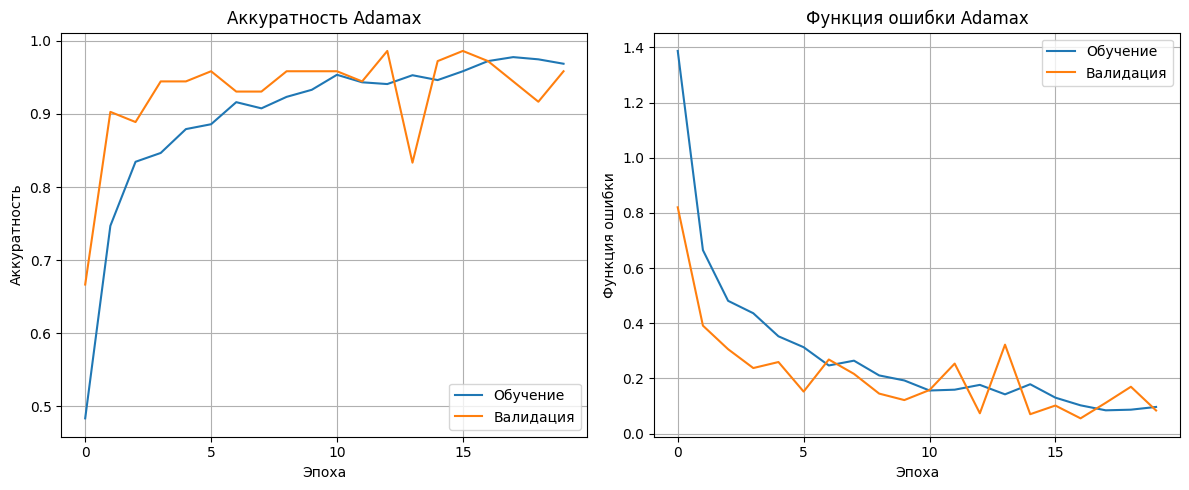

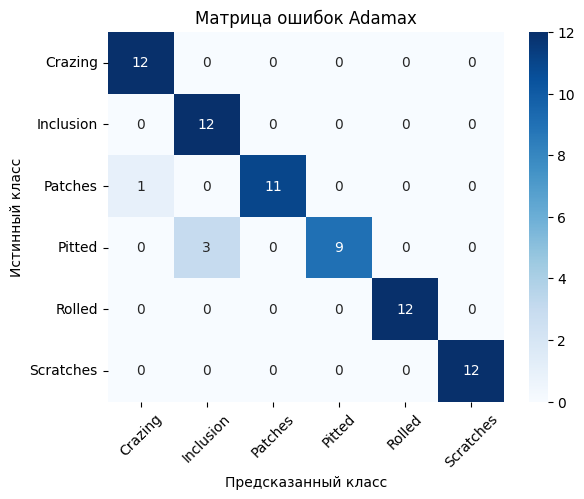


Метрики:
              precision    recall  f1-score   support

     Crazing       0.92      1.00      0.96        12
   Inclusion       0.80      1.00      0.89        12
     Patches       1.00      0.92      0.96        12
      Pitted       1.00      0.75      0.86        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      1.00      1.00        12

    accuracy                           0.94        72
   macro avg       0.95      0.94      0.94        72
weighted avg       0.95      0.94      0.94        72


Параметры: epochs=20, batch_size=32, dropout=0.3

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Adamax, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9614, Training Loss:    0.1100
Validation Accuracy:  0.9722, Validation Loss:  0.1205

Результаты тестирования:
Test Accuracy:        0.9583, Test Loss:        0.1613



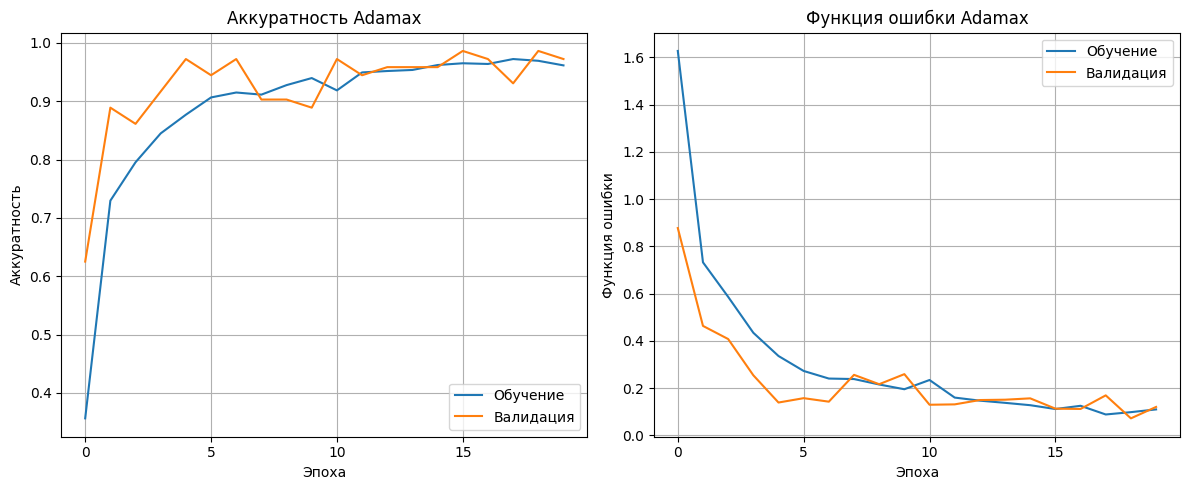

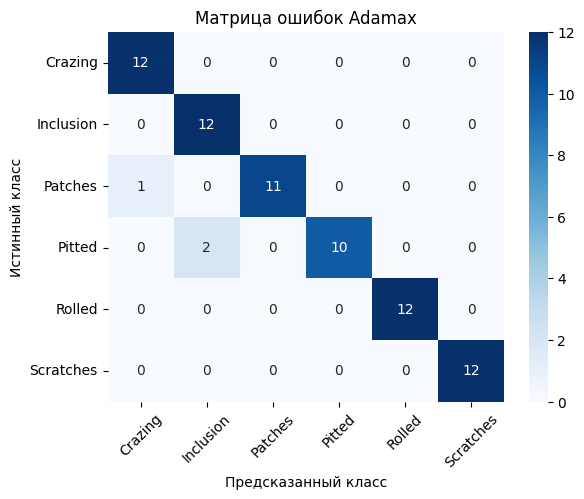


Метрики:
              precision    recall  f1-score   support

     Crazing       0.92      1.00      0.96        12
   Inclusion       0.86      1.00      0.92        12
     Patches       1.00      0.92      0.96        12
      Pitted       1.00      0.83      0.91        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      1.00      1.00        12

    accuracy                           0.96        72
   macro avg       0.96      0.96      0.96        72
weighted avg       0.96      0.96      0.96        72


Параметры: epochs=20, batch_size=64, dropout=0.3

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Adamax, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9457, Training Loss:    0.1608
Validation Accuracy:  0.9028, Validation Loss:  0.2599

Результаты тестирования:
Test Accuracy:        0.8889, Test Loss:        0.3352



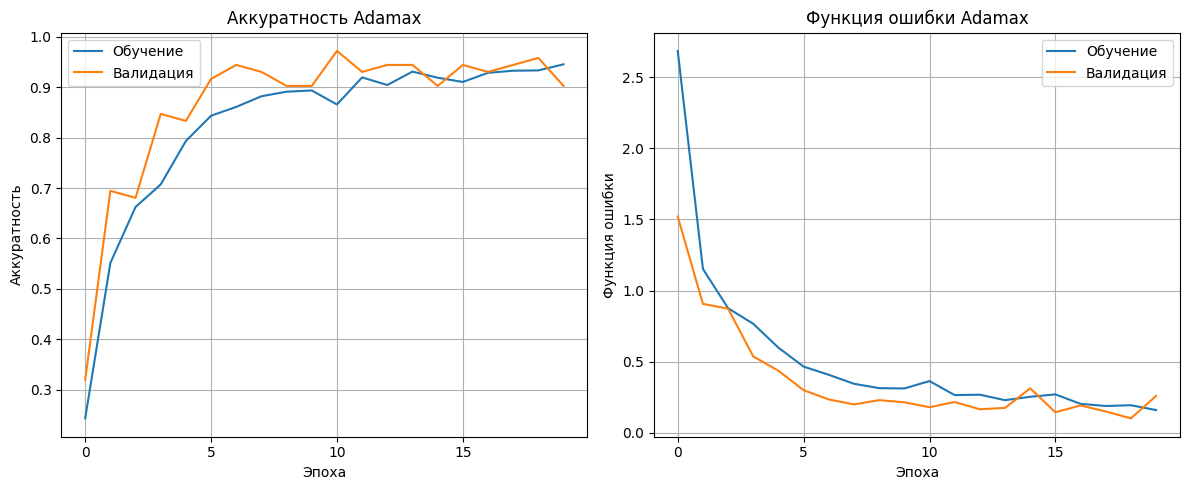

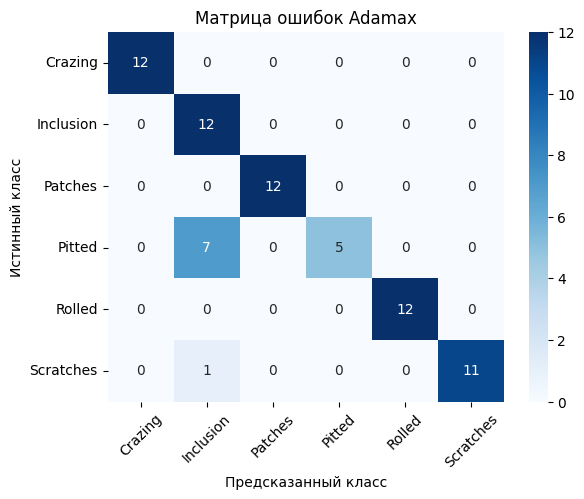


Метрики:
              precision    recall  f1-score   support

     Crazing       1.00      1.00      1.00        12
   Inclusion       0.60      1.00      0.75        12
     Patches       1.00      1.00      1.00        12
      Pitted       1.00      0.42      0.59        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      0.92      0.96        12

    accuracy                           0.89        72
   macro avg       0.93      0.89      0.88        72
weighted avg       0.93      0.89      0.88        72



In [ ]:
EPOCHS = 20
BATCH_SIZE = 32
DROPOUT_RATE = 0.3
OPTIMIZER = 'Adamax'

for bs in [16, 32, 64]:
  print(f"\nПараметры: epochs={EPOCHS}, batch_size={bs}, dropout={DROPOUT_RATE}\n")
  train_data, valid_data, test_data = load_dataset(path, bs)
  model = build_cnn_model(OPTIMIZER, DROPOUT_RATE)
  train_and_evaluate_model(model, OPTIMIZER, train_data, valid_data, test_data, EPOCHS)

#### Nadam:


Параметры: epochs=20, batch_size=16, dropout=0.3

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Nadam, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9903, Training Loss:    0.0330
Validation Accuracy:  0.9583, Validation Loss:  0.0983

Результаты тестирования:
Test Accuracy:        0.9583, Test Loss:        0.1224



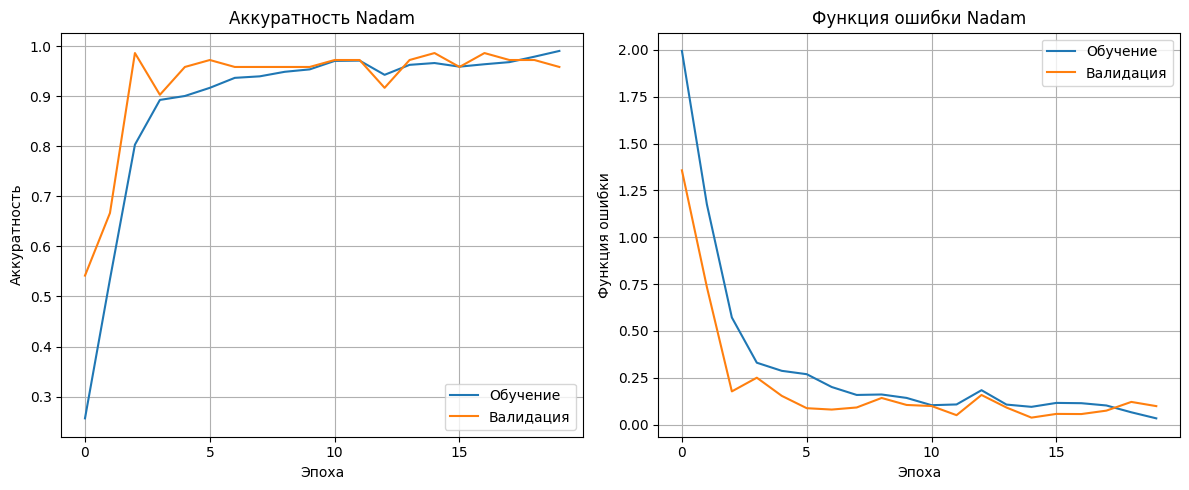

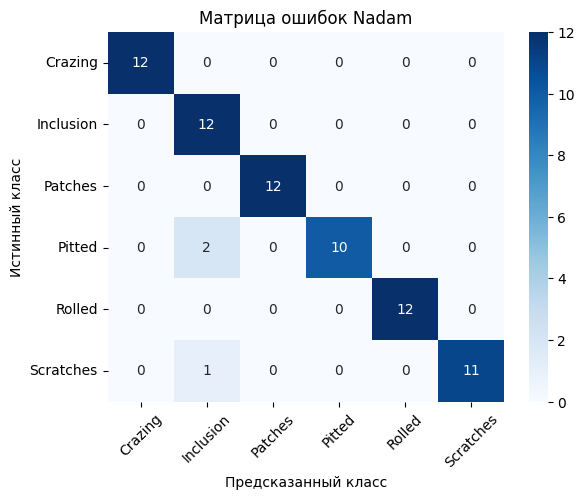


Метрики:
              precision    recall  f1-score   support

     Crazing       1.00      1.00      1.00        12
   Inclusion       0.80      1.00      0.89        12
     Patches       1.00      1.00      1.00        12
      Pitted       1.00      0.83      0.91        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      0.92      0.96        12

    accuracy                           0.96        72
   macro avg       0.97      0.96      0.96        72
weighted avg       0.97      0.96      0.96        72


Параметры: epochs=20, batch_size=32, dropout=0.3

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Nadam, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9897, Training Loss:    0.0459
Validation Accuracy:  0.9444, Validation Loss:  0.2954

Результаты тестирования:
Test Accuracy:        0.9444, Test Loss:        0.1057



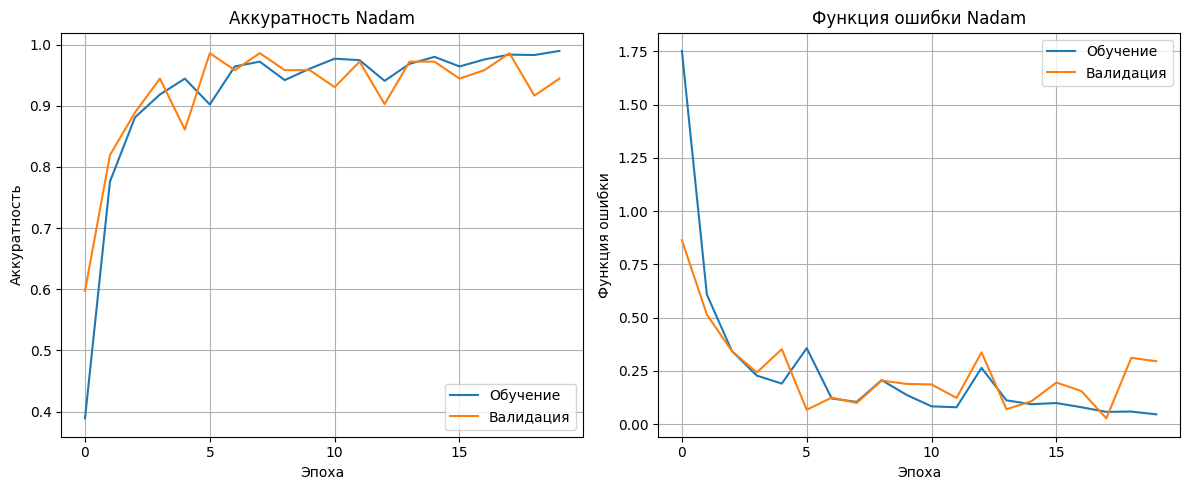

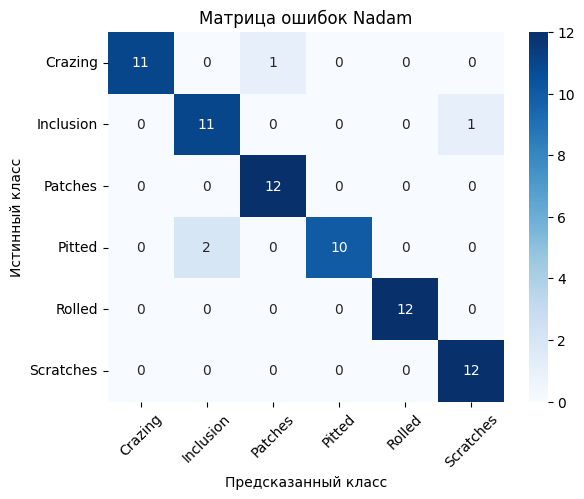


Метрики:
              precision    recall  f1-score   support

     Crazing       1.00      0.92      0.96        12
   Inclusion       0.85      0.92      0.88        12
     Patches       0.92      1.00      0.96        12
      Pitted       1.00      0.83      0.91        12
      Rolled       1.00      1.00      1.00        12
   Scratches       0.92      1.00      0.96        12

    accuracy                           0.94        72
   macro avg       0.95      0.94      0.94        72
weighted avg       0.95      0.94      0.94        72


Параметры: epochs=20, batch_size=64, dropout=0.3

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Nadam, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9728, Training Loss:    0.0855
Validation Accuracy:  0.9583, Validation Loss:  0.0729

Результаты тестирования:
Test Accuracy:        0.9444, Test Loss:        0.1475



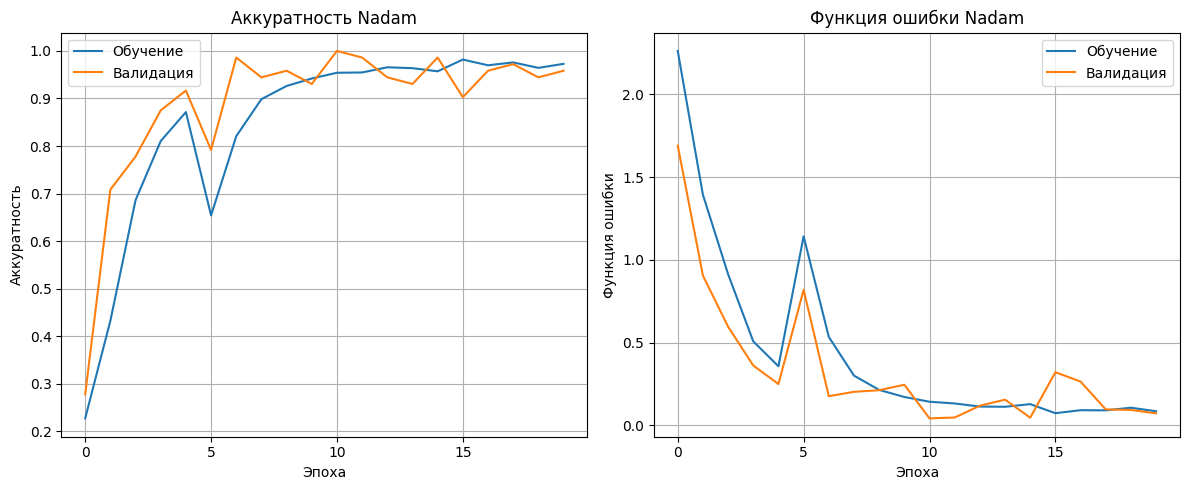

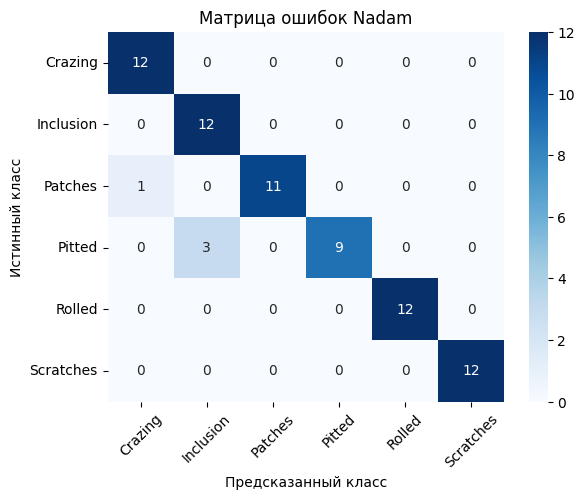


Метрики:
              precision    recall  f1-score   support

     Crazing       0.92      1.00      0.96        12
   Inclusion       0.80      1.00      0.89        12
     Patches       1.00      0.92      0.96        12
      Pitted       1.00      0.75      0.86        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      1.00      1.00        12

    accuracy                           0.94        72
   macro avg       0.95      0.94      0.94        72
weighted avg       0.95      0.94      0.94        72



In [ ]:
EPOCHS = 20
BATCH_SIZE = 32
DROPOUT_RATE = 0.3
OPTIMIZER = 'Nadam'

for bs in [16, 32, 64]:
  print(f"\nПараметры: epochs={EPOCHS}, batch_size={bs}, dropout={DROPOUT_RATE}\n")
  train_data, valid_data, test_data = load_dataset(path, bs)
  model = build_cnn_model(OPTIMIZER, DROPOUT_RATE)
  train_and_evaluate_model(model, OPTIMIZER, train_data, valid_data, test_data, EPOCHS)

### 7. Исследование зависимости функции ошибки и accuracy от уровня исключения нейронов

#### Adamax:


Параметры: epochs=20, batch_size=32, dropout=0.1

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Adamax, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9801, Training Loss:    0.0758
Validation Accuracy:  0.9583, Validation Loss:  0.1770

Результаты тестирования:
Test Accuracy:        0.9444, Test Loss:        0.1518



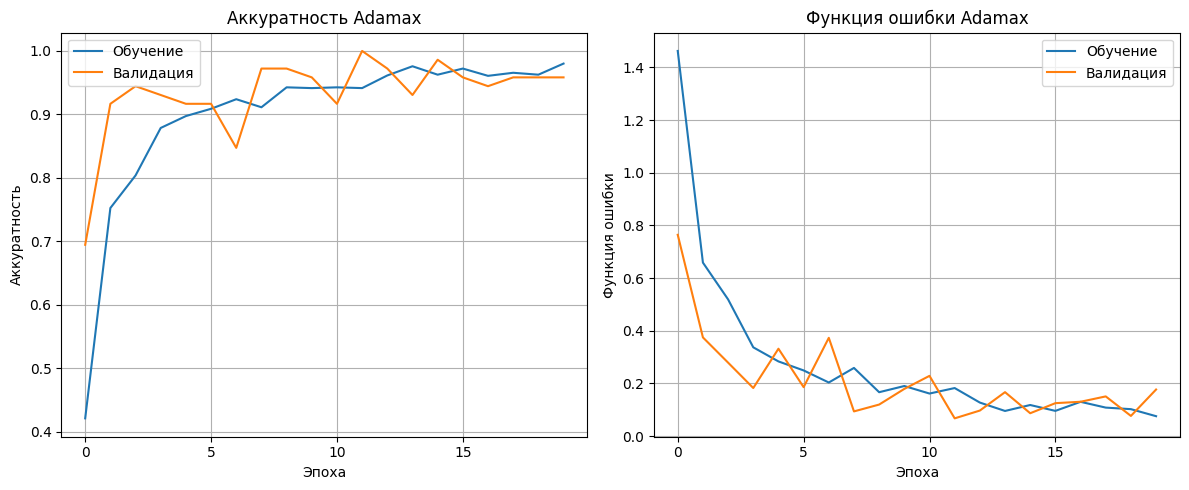

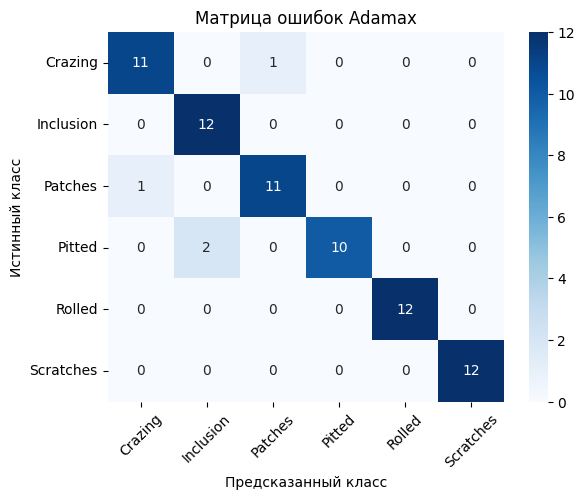


Метрики:
              precision    recall  f1-score   support

     Crazing       0.92      0.92      0.92        12
   Inclusion       0.86      1.00      0.92        12
     Patches       0.92      0.92      0.92        12
      Pitted       1.00      0.83      0.91        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      1.00      1.00        12

    accuracy                           0.94        72
   macro avg       0.95      0.94      0.94        72
weighted avg       0.95      0.94      0.94        72


Параметры: epochs=20, batch_size=32, dropout=0.2

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Adamax, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9553, Training Loss:    0.1322
Validation Accuracy:  0.9444, Validation Loss:  0.0943

Результаты тестирования:
Test Accuracy:        0.9306, Test Loss:        0.2536



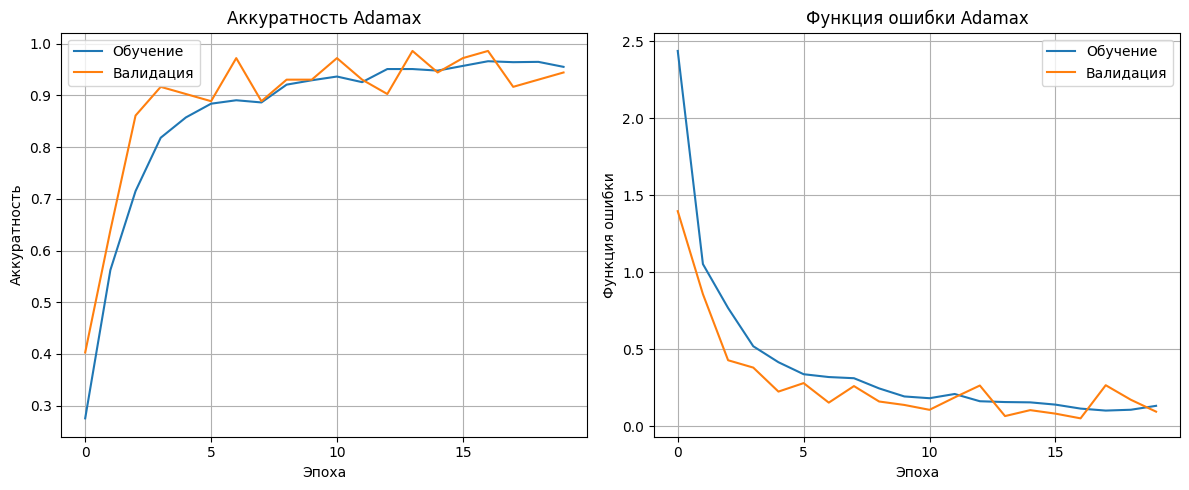

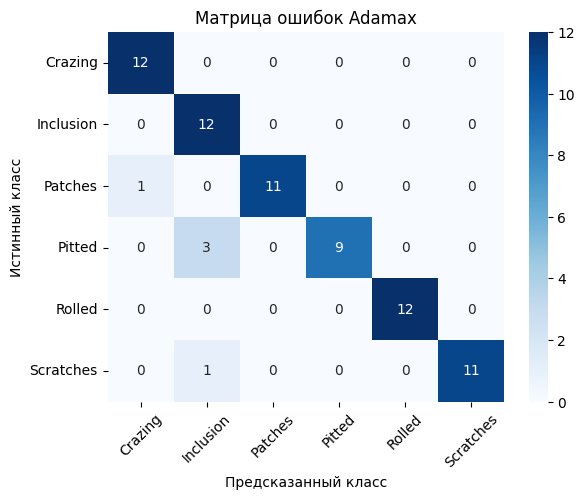


Метрики:
              precision    recall  f1-score   support

     Crazing       0.92      1.00      0.96        12
   Inclusion       0.75      1.00      0.86        12
     Patches       1.00      0.92      0.96        12
      Pitted       1.00      0.75      0.86        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      0.92      0.96        12

    accuracy                           0.93        72
   macro avg       0.95      0.93      0.93        72
weighted avg       0.95      0.93      0.93        72


Параметры: epochs=20, batch_size=32, dropout=0.3

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Adamax, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9710, Training Loss:    0.0894
Validation Accuracy:  0.9722, Validation Loss:  0.0621

Результаты тестирования:
Test Accuracy:        0.9444, Test Loss:        0.1446



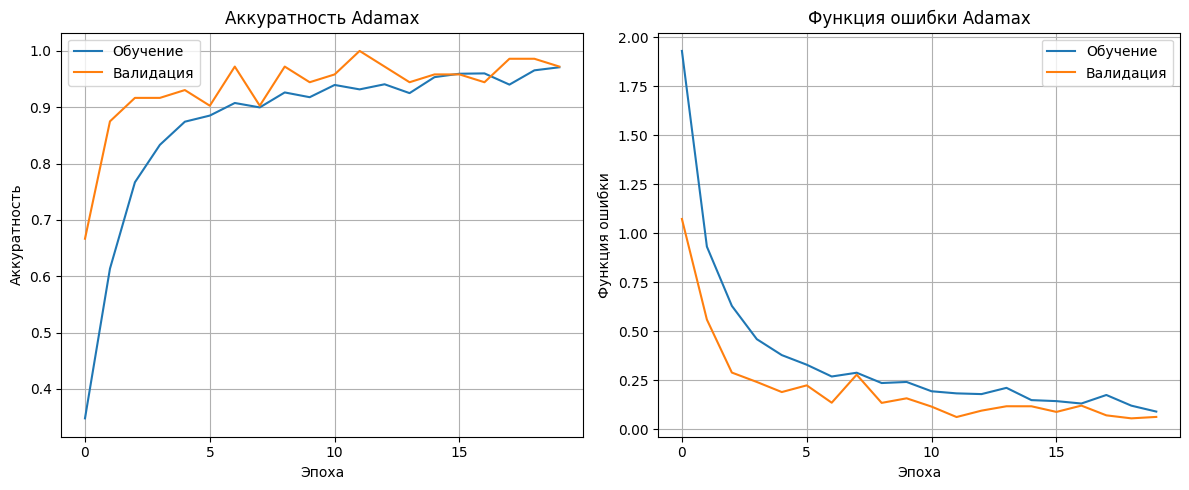

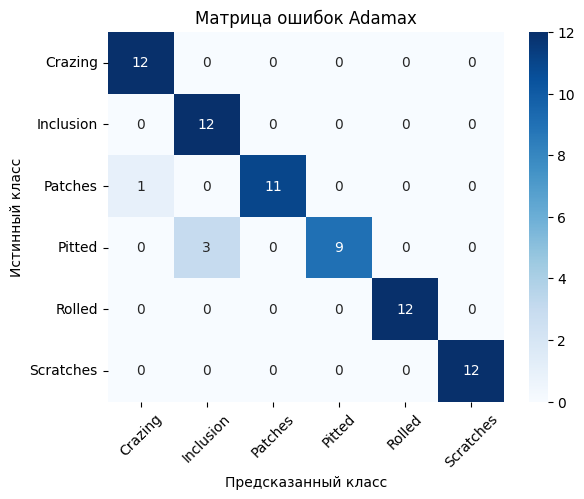


Метрики:
              precision    recall  f1-score   support

     Crazing       0.92      1.00      0.96        12
   Inclusion       0.80      1.00      0.89        12
     Patches       1.00      0.92      0.96        12
      Pitted       1.00      0.75      0.86        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      1.00      1.00        12

    accuracy                           0.94        72
   macro avg       0.95      0.94      0.94        72
weighted avg       0.95      0.94      0.94        72


Параметры: epochs=20, batch_size=32, dropout=0.4

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Adamax, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9523, Training Loss:    0.1389
Validation Accuracy:  0.9444, Validation Loss:  0.1102

Результаты тестирования:
Test Accuracy:        0.9306, Test Loss:        0.2242



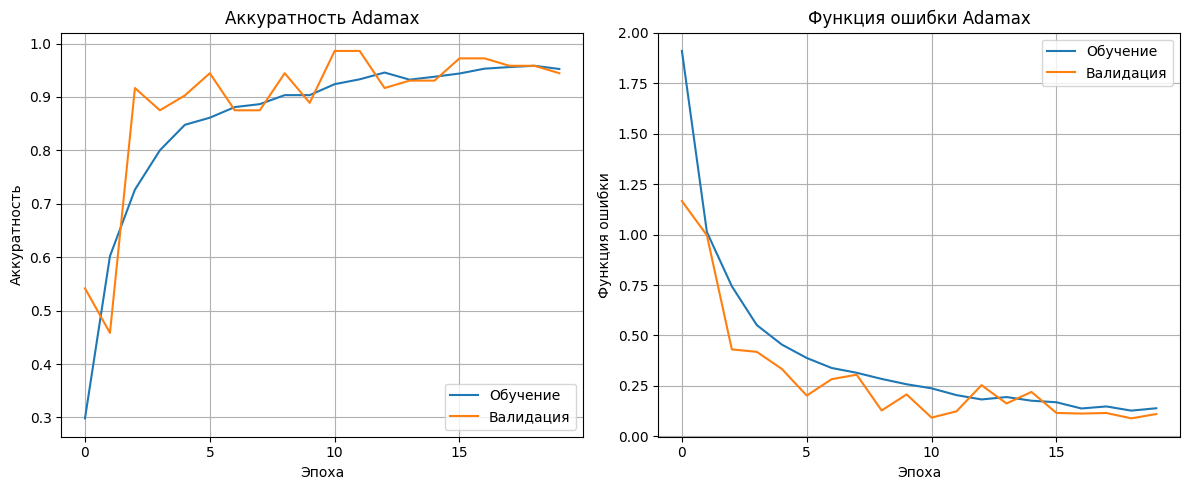

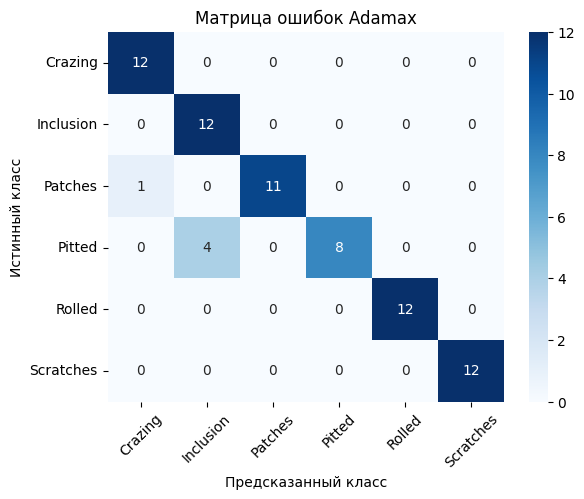


Метрики:
              precision    recall  f1-score   support

     Crazing       0.92      1.00      0.96        12
   Inclusion       0.75      1.00      0.86        12
     Patches       1.00      0.92      0.96        12
      Pitted       1.00      0.67      0.80        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      1.00      1.00        12

    accuracy                           0.93        72
   macro avg       0.95      0.93      0.93        72
weighted avg       0.95      0.93      0.93        72



In [ ]:
EPOCHS = 20
BATCH_SIZE = 32
DROPOUT_RATE = 0.3
OPTIMIZER = 'Adamax'

for dr in [0.1, 0.2, 0.3, 0.4]:
  print(f"\nПараметры: epochs={EPOCHS}, batch_size={BATCH_SIZE}, dropout={dr}\n")
  train_data, valid_data, test_data = load_dataset(path, BATCH_SIZE)
  model = build_cnn_model(OPTIMIZER, dr)
  train_and_evaluate_model(model, OPTIMIZER, train_data, valid_data, test_data, EPOCHS)

#### Nadam:


Параметры: epochs=20, batch_size=16, dropout=0.1

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Nadam, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9662, Training Loss:    0.1038
Validation Accuracy:  0.9722, Validation Loss:  0.0880

Результаты тестирования:
Test Accuracy:        0.9722, Test Loss:        0.1362



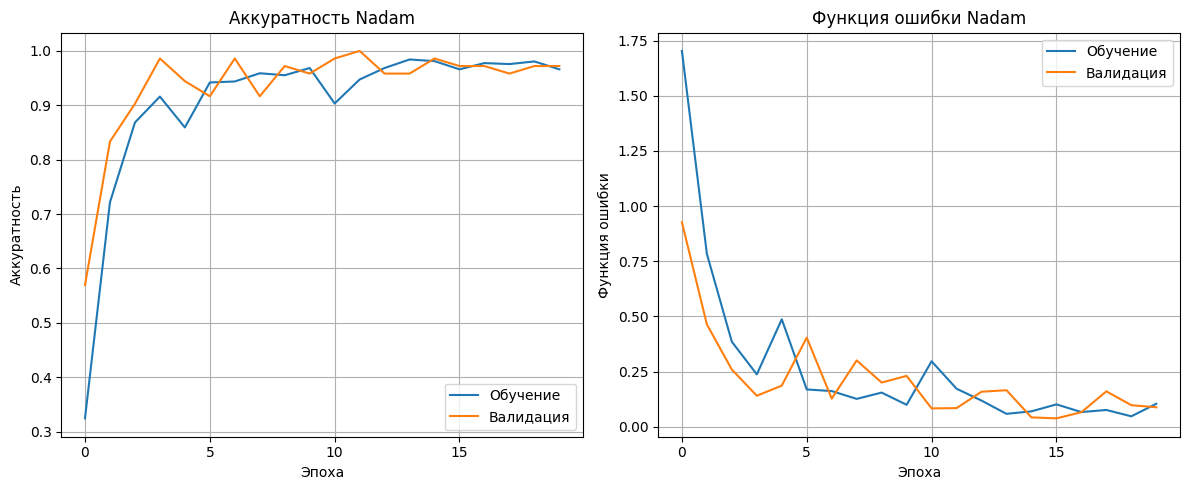

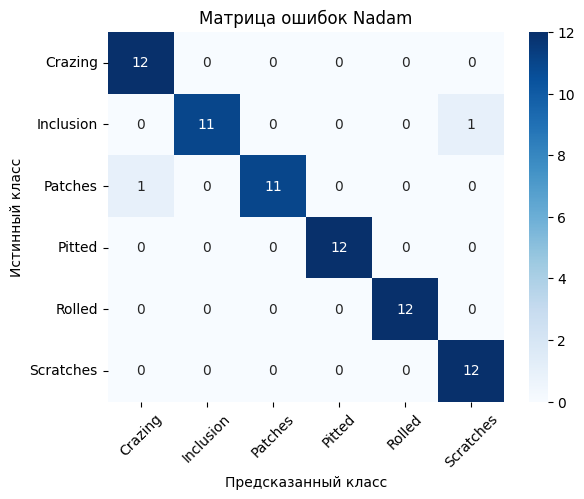


Метрики:
              precision    recall  f1-score   support

     Crazing       0.92      1.00      0.96        12
   Inclusion       1.00      0.92      0.96        12
     Patches       1.00      0.92      0.96        12
      Pitted       1.00      1.00      1.00        12
      Rolled       1.00      1.00      1.00        12
   Scratches       0.92      1.00      0.96        12

    accuracy                           0.97        72
   macro avg       0.97      0.97      0.97        72
weighted avg       0.97      0.97      0.97        72


Параметры: epochs=20, batch_size=16, dropout=0.2

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Nadam, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9801, Training Loss:    0.0601
Validation Accuracy:  0.9722, Validation Loss:  0.0452

Результаты тестирования:
Test Accuracy:        0.9444, Test Loss:        0.3314



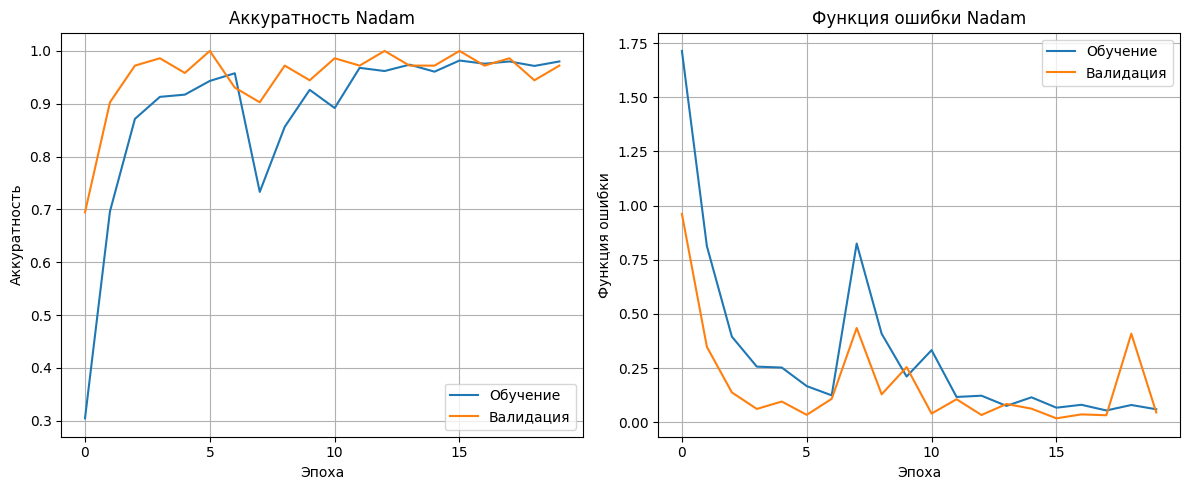

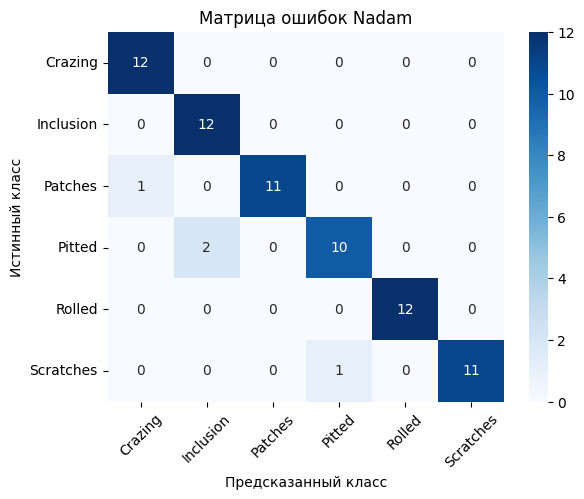


Метрики:
              precision    recall  f1-score   support

     Crazing       0.92      1.00      0.96        12
   Inclusion       0.86      1.00      0.92        12
     Patches       1.00      0.92      0.96        12
      Pitted       0.91      0.83      0.87        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      0.92      0.96        12

    accuracy                           0.94        72
   macro avg       0.95      0.94      0.94        72
weighted avg       0.95      0.94      0.94        72


Параметры: epochs=20, batch_size=16, dropout=0.3

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Nadam, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9728, Training Loss:    0.0977
Validation Accuracy:  0.9583, Validation Loss:  0.1070

Результаты тестирования:
Test Accuracy:        0.9444, Test Loss:        0.2537



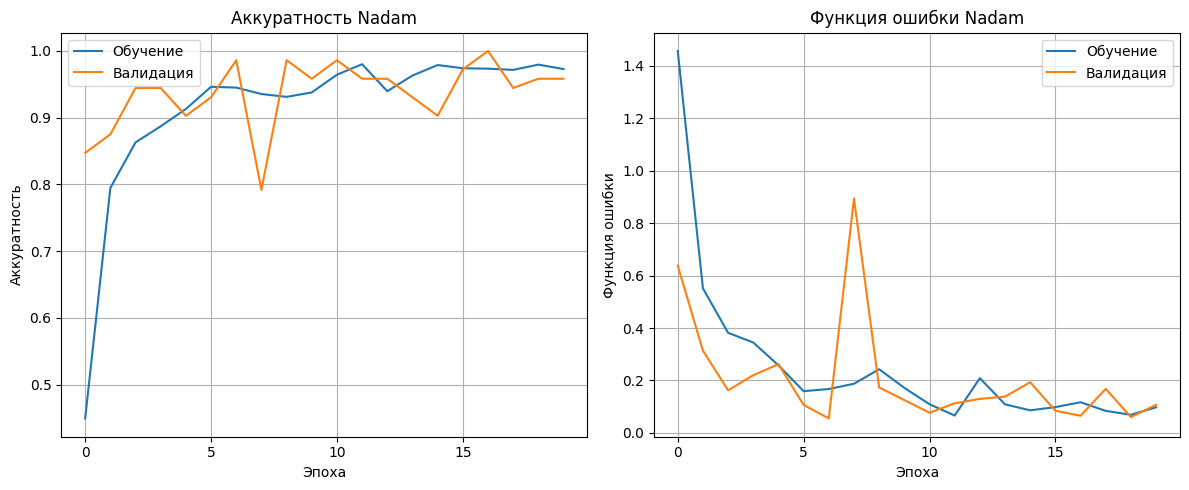

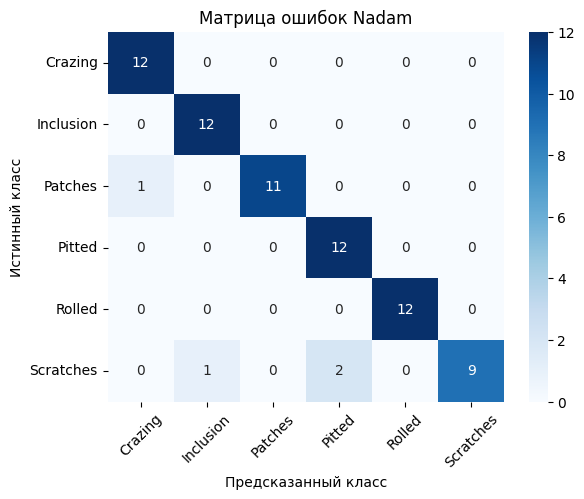


Метрики:
              precision    recall  f1-score   support

     Crazing       0.92      1.00      0.96        12
   Inclusion       0.92      1.00      0.96        12
     Patches       1.00      0.92      0.96        12
      Pitted       0.86      1.00      0.92        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      0.75      0.86        12

    accuracy                           0.94        72
   macro avg       0.95      0.94      0.94        72
weighted avg       0.95      0.94      0.94        72


Параметры: epochs=20, batch_size=16, dropout=0.4

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Nadam, learning_rate=0.001

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9644, Training Loss:    0.1188
Validation Accuracy:  0.9861, Validation Loss:  0.0724

Результаты тестирования:
Test Accuracy:        0.9722, Test Loss:        0.0927



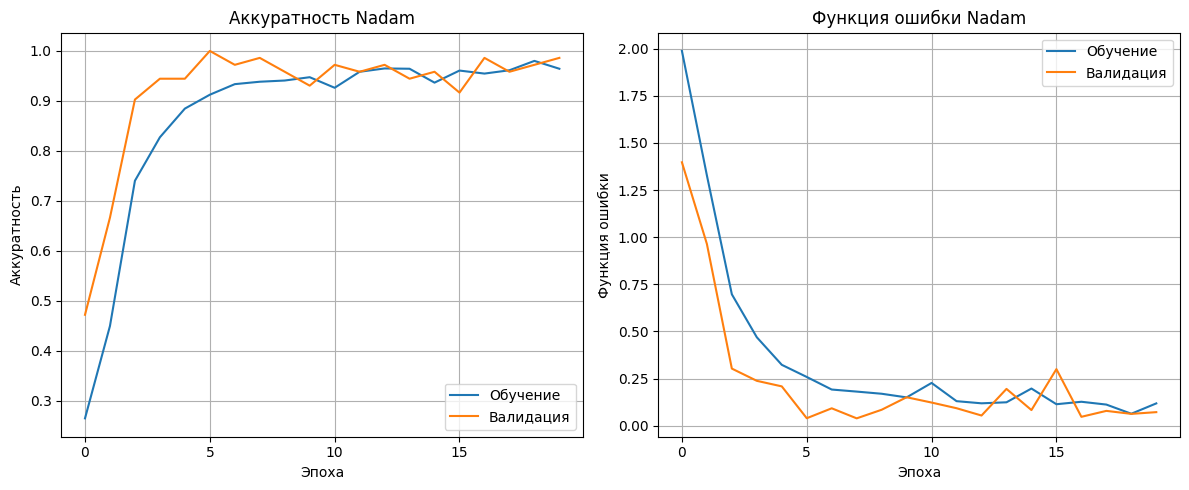

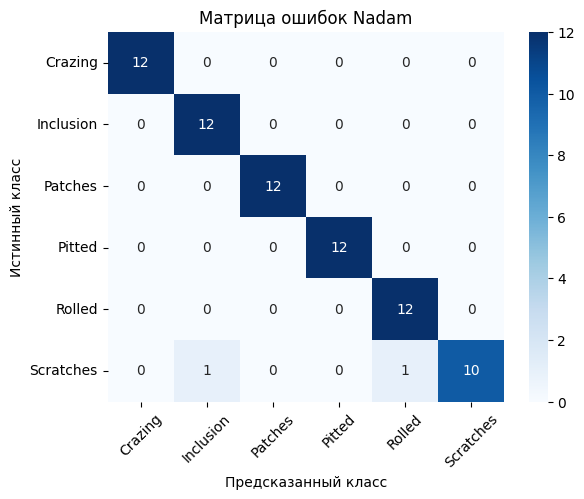


Метрики:
              precision    recall  f1-score   support

     Crazing       1.00      1.00      1.00        12
   Inclusion       0.92      1.00      0.96        12
     Patches       1.00      1.00      1.00        12
      Pitted       1.00      1.00      1.00        12
      Rolled       0.92      1.00      0.96        12
   Scratches       1.00      0.83      0.91        12

    accuracy                           0.97        72
   macro avg       0.97      0.97      0.97        72
weighted avg       0.97      0.97      0.97        72



In [ ]:
EPOCHS = 20
BATCH_SIZE = 16
DROPOUT_RATE = 0.3
OPTIMIZER = 'Nadam'

for dr in [0.1, 0.2, 0.3, 0.4]:
  print(f"\nПараметры: epochs={EPOCHS}, batch_size={BATCH_SIZE}, dropout={dr}\n")
  train_data, valid_data, test_data = load_dataset(path, BATCH_SIZE)
  model = build_cnn_model(OPTIMIZER, dr)
  train_and_evaluate_model(model, OPTIMIZER, train_data, valid_data, test_data, EPOCHS)

### 8. Результаты исследований

#### Adamax:


Параметры: epochs=20, batch_size=32, dropout=0.3

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Adamax, learning_rate=0.002

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9722, Training Loss:    0.0876
Validation Accuracy:  0.9583, Validation Loss:  0.1256

Результаты тестирования:
Test Accuracy:        0.9583, Test Loss:        0.1424



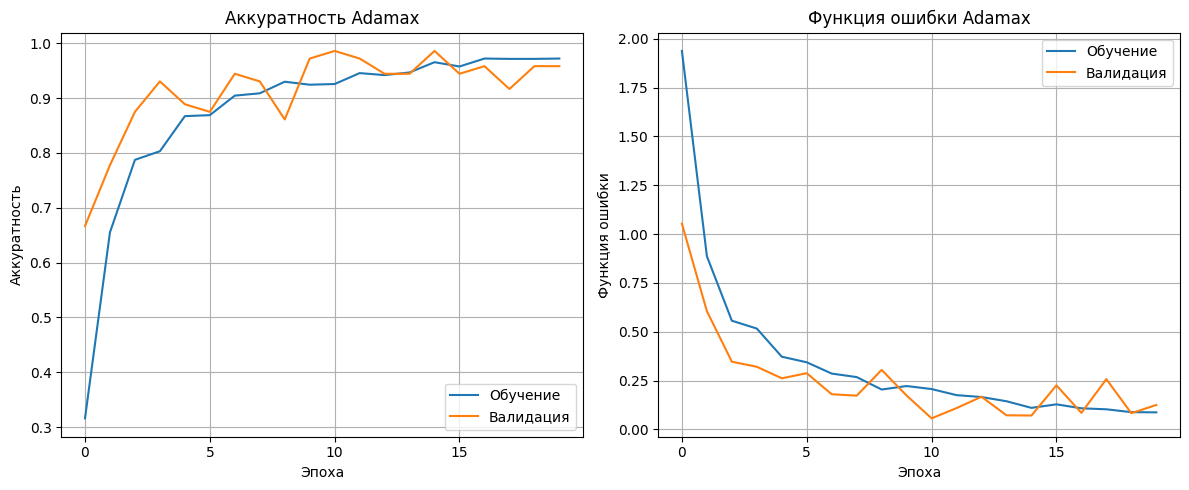

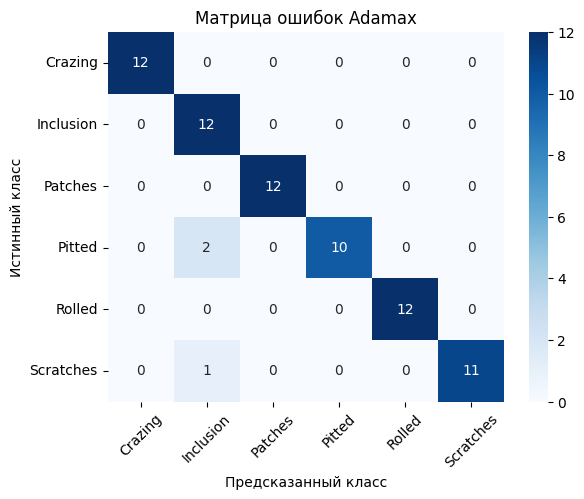


Метрики:
              precision    recall  f1-score   support

     Crazing       1.00      1.00      1.00        12
   Inclusion       0.80      1.00      0.89        12
     Patches       1.00      1.00      1.00        12
      Pitted       1.00      0.83      0.91        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      0.92      0.96        12

    accuracy                           0.96        72
   macro avg       0.97      0.96      0.96        72
weighted avg       0.97      0.96      0.96        72



In [11]:
EPOCHS = 20
BATCH_SIZE = 32
DROPOUT_RATE = 0.3
OPTIMIZER = 'Adamax'

print(f"\nПараметры: epochs={EPOCHS}, batch_size={BATCH_SIZE}, dropout={DROPOUT_RATE}\n")
train_data, valid_data, test_data = load_dataset(path, BATCH_SIZE)
model = build_cnn_model(OPTIMIZER, DROPOUT_RATE, learning_rate=0.002)
train_and_evaluate_model(model, OPTIMIZER, train_data, valid_data, test_data, EPOCHS)

#### Nadam:


Параметры: epochs=20, batch_size=16, dropout=0.4

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.

Модель создана: optimizer=Nadam, learning_rate=0.0005

Обучение модели...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Результаты обучения:
Training Accuracy:    0.9734, Training Loss:    0.0939
Validation Accuracy:  0.9167, Validation Loss:  0.1307

Результаты тестирования:
Test Accuracy:        0.9861, Test Loss:        0.1079



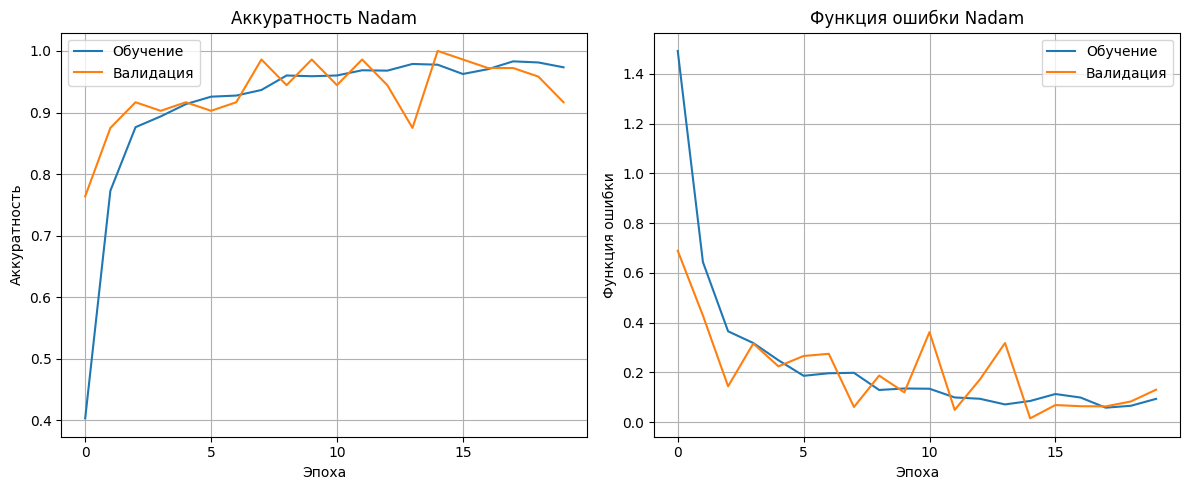

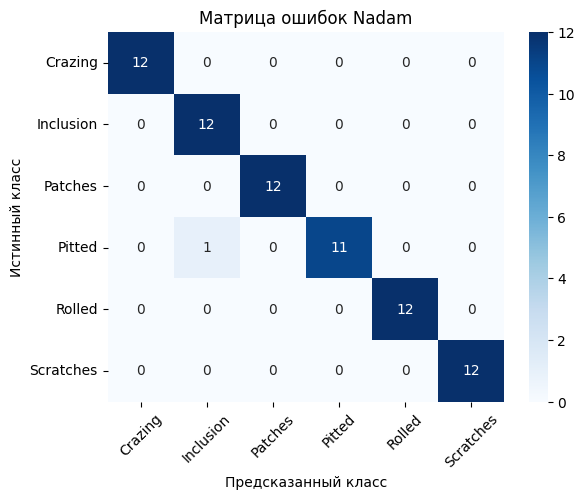


Метрики:
              precision    recall  f1-score   support

     Crazing       1.00      1.00      1.00        12
   Inclusion       0.92      1.00      0.96        12
     Patches       1.00      1.00      1.00        12
      Pitted       1.00      0.92      0.96        12
      Rolled       1.00      1.00      1.00        12
   Scratches       1.00      1.00      1.00        12

    accuracy                           0.99        72
   macro avg       0.99      0.99      0.99        72
weighted avg       0.99      0.99      0.99        72



In [12]:
EPOCHS = 20
BATCH_SIZE = 16
DROPOUT_RATE = 0.4
OPTIMIZER = 'Nadam'

print(f"\nПараметры: epochs={EPOCHS}, batch_size={BATCH_SIZE}, dropout={DROPOUT_RATE}\n")
train_data, valid_data, test_data = load_dataset(path, BATCH_SIZE)
model = build_cnn_model(OPTIMIZER, DROPOUT_RATE, learning_rate=0.0005)
train_and_evaluate_model(model, OPTIMIZER, train_data, valid_data, test_data, EPOCHS)